<a href="https://colab.research.google.com/github/vgayathri13/VRSU/blob/main/SemanticAndInstanceSegmentationProgram9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Obstacles detected: 3
  Obstacle 1: centroid=(24.5,29.5), area=400px
  Obstacle 2: centroid=(69.5,42.0), area=500px
  Obstacle 3: centroid=(49.5,77.0), area=300px

Navigation decision: Turn LEFT  — obstacle on the right


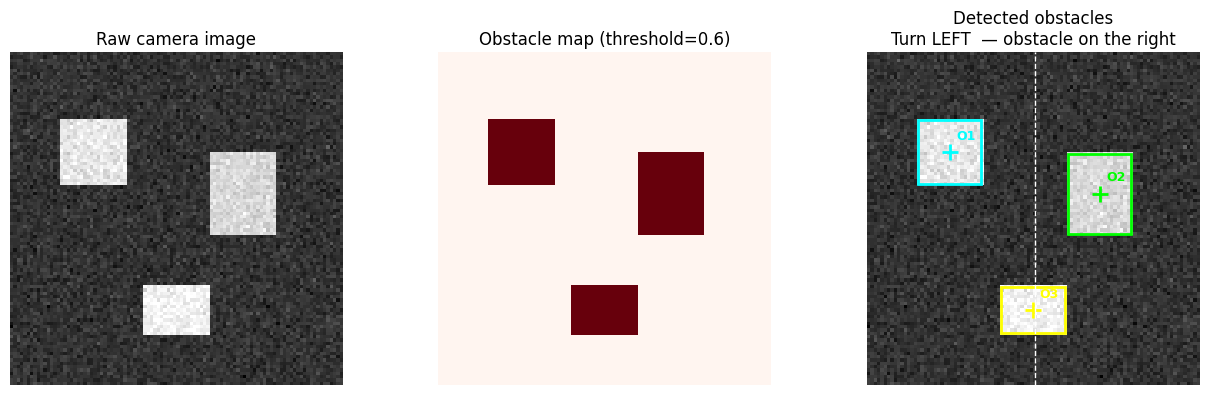

Plot saved as robotic_navigation.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# ─── Simulate a grayscale depth/camera image ──────────────────
np.random.seed(42)
image_size = (100, 100)

# Create a scene: dark background (far), bright areas (close)
scene = np.ones(image_size) * 0.2          # background (far)

# Add obstacles (bright blobs)
scene[20:40, 15:35] = 0.9    # obstacle 1 (left)
scene[30:55, 60:80] = 0.85   # obstacle 2 (right)
scene[70:85, 40:60] = 0.95   # obstacle 3 (center-bottom)

# Add Gaussian noise
scene += np.random.normal(0, 0.05, image_size)
scene = np.clip(scene, 0, 1)

# ─── Step 1: Threshold to detect obstacles ────────────────────
threshold = 0.6
binary_map = (scene > threshold).astype(int)

# ─── Step 2: Label connected obstacle regions ─────────────────
labeled_map, num_obstacles = label(binary_map)
print(f"Obstacles detected: {num_obstacles}")

# ─── Step 3: Find bounding boxes and centroids ────────────────
obstacle_info = []
for obj_id in range(1, num_obstacles + 1):
    coords = np.argwhere(labeled_map == obj_id)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    cy, cx = coords.mean(axis=0)
    area = len(coords)
    obstacle_info.append({
        "id": obj_id, "centroid": (cx, cy),
        "bbox": (x_min, y_min, x_max, y_max), "area": area
    })
    print(f"  Obstacle {obj_id}: centroid=({cx:.1f},{cy:.1f}), "
          f"area={area}px")

# ─── Step 4: Simple navigation decision ───────────────────────
center_x = image_size[1] / 2

def navigate(obstacles, center):
    if not obstacles:
        return "Move FORWARD — path is clear"
    # Find the closest (largest) obstacle
    main = max(obstacles, key=lambda o: o["area"])
    cx = main["centroid"][0]
    if cx < center - 10:
        return "Turn RIGHT — obstacle on the left"
    elif cx > center + 10:
        return "Turn LEFT  — obstacle on the right"
    else:
        return "STOP       — obstacle directly ahead"

decision = navigate(obstacle_info, center_x)
print(f"\nNavigation decision: {decision}")

# ─── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(scene, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Raw camera image")

axes[1].imshow(binary_map, cmap='Reds')
axes[1].set_title(f"Obstacle map (threshold={threshold})")

axes[2].imshow(scene, cmap='gray', vmin=0, vmax=1)
colors = ['cyan','lime','yellow','magenta']
for obs in obstacle_info:
    x0,y0,x1,y1 = obs["bbox"]
    cx,cy = obs["centroid"]
    col = colors[(obs["id"]-1) % len(colors)]
    rect = plt.Rectangle((x0,y0), x1-x0, y1-y0,
                          edgecolor=col, facecolor='none', lw=2)
    axes[2].add_patch(rect)
    axes[2].plot(cx, cy, '+', color=col, ms=12, mew=2)
    axes[2].text(cx+2, cy-4, f"O{obs['id']}",
                 color=col, fontsize=9, fontweight='bold')

axes[2].set_title(f"Detected obstacles\n{decision}")
axes[2].axvline(center_x, color='white', lw=1, ls='--')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig("robotic_navigation.png", dpi=100)
plt.show()
print("Plot saved as robotic_navigation.png")